In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from IPython.display import display
import warnings 
warnings.filterwarnings('ignore')
from sklearn.svm import SVR
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

Gamma controls the influence of a single training data point. A small gamma gives a smoother decision boundary, while a large gamma creates a more complex boundary and increases the risk of overfitting.

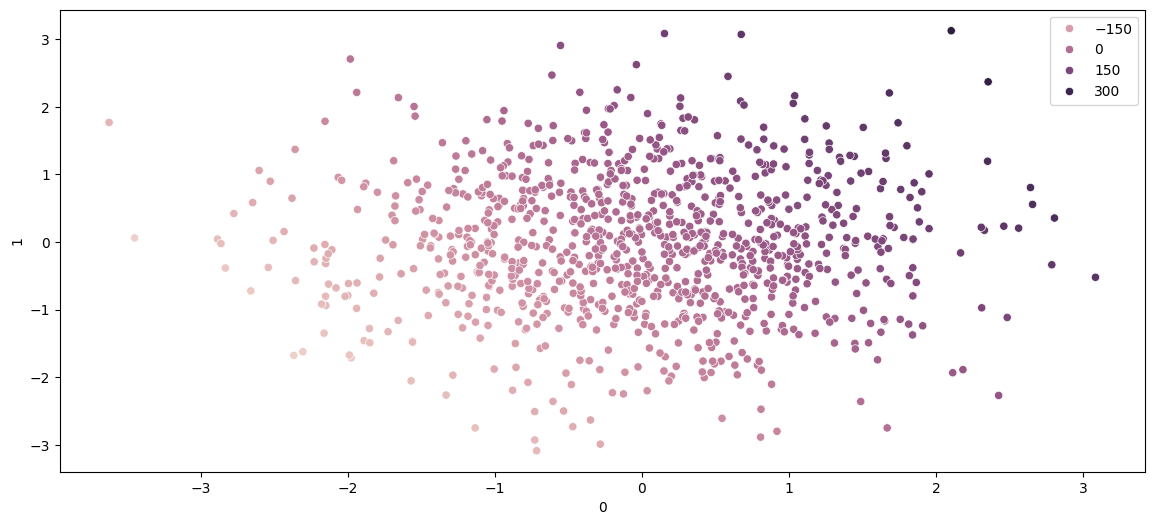

(750, 2)

array([[84.52403194, 54.12348679]])

r2_score 0.9991018000266251)
Fitting 5 folds for each of 140 candidates, totalling 700 fits
[CV] END ........C=0.1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=1, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=2, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=2, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=2, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=2, kernel=linear; total time=   0.0s
[CV] END ........C=0.1, epsilon=0.01, gamma=2, kernel=linear; total time=   0.0s
[CV] END .....C=0.1, epsilon=0.01, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .....C=0

In [2]:
x,y=make_regression(n_samples= 1000, n_features=2,n_targets=1,noise=3)
plt.figure(figsize=(14,6))
sns.scatterplot(x=pd.DataFrame(x)[0],y=pd.DataFrame(x)[1],hue=y)
plt.legend()
plt.show()
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
display(x_train.shape)
model=SVR(kernel='linear')
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
display(model.coef_)
r_score=r2_score(y_test,y_pred)
print(f"r2_score {r_score})")

#-------------------------------------------------------------------------------------------------------------------
param_grid={
    'C':[0.1,0.5,1,5,10],
    'gamma':[1,2,.01,0.2,0.5,0.001,0.002],
    'kernel':['linear'],
    'epsilon':[0.01,0.1,0.2,0.3] #Epsilon (ε) is the error tolerance in SVR. Errors inside the epsilon tube are ignored, and only errors outside the tube are penalized.
}

grid_model=GridSearchCV(estimator=SVR(),param_grid=param_grid,cv=5,verbose=2)
grid_model.fit(x_train,y_train)
y_grid_pred=grid_model.predict(x_test)
r2=r2_score(y_grid_pred,y_test)
print(f"r2score {r2}")
print(f"best parameter for this dataset {grid_model.best_params_}")
